# Import Library & Set Globals

In [1]:
# base
import os
import sys
import gc
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# single cell
import anndata as ad
import scanpy as sc
import decoupler as dc
import gseapy as gp

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
study = "Emont2022"
data_folder = DATADIR / "cellranger" / "Emont_download"

%matplotlib inline
mpl.rcdefaults()
gc.collect()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


2025-12-29 16:59:04 | [INFO] cffi mode is CFFI_MODE.ANY
2025-12-29 16:59:04 | [INFO] R home found: /opt/R/4.4.1/lib/R
2025-12-29 16:59:05 | [INFO] R library path: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2025-12-29 16:59:05 | [INFO] LD_LIBRARY_PATH: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2025-12-29 16:59:05 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2025-12-29 16:59:05 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/mnt/DATA/home/ethung", R: "/mnt/DATA/home/ethung/spatial_seq/src/notebooks/single_cell"
2025-12-29 16:59:05 | [INFO] R is already initialized. No need to initialize.


403

# Access adata

In [58]:
adata = sc.read_10x_mtx(DATADIR / "raw" / "Emont2022")
annotations = pd.read_csv(
    data_folder / "GSE176171_cell_metadata.tsv.gz", sep="\t", index_col=0
)
annotations = annotations[annotations["species__ontology_label"] == "Mus musculus"]
adata.obs = annotations.loc[adata.obs_names.tolist()]
adata.layers["counts"] = adata.X.copy()

In [59]:
# save
adata.obs.rename(columns={"biosample_id": "Identifier"}, inplace=True)
nan_cols = adata.obs.columns[adata.obs.dtypes == "object"]
adata.obs[nan_cols] = adata.obs[nan_cols].astype(str)

savedir = DATADIR / "processed" / "single cell" / study
os.makedirs(savedir, exist_ok=True)
adata.write_zarr(savedir / "cleaned")
gc.collect()

... storing 'Identifier' as categorical
... storing 'biosample_type' as categorical
... storing 'library_preparation_protocol__ontology_id' as categorical
... storing 'library_preparation_protocol__ontology_label' as categorical
... storing 'donor_id' as categorical
... storing 'species__ontology_id' as categorical
... storing 'species__ontology_label' as categorical
... storing 'organ__ontology_id' as categorical
... storing 'organ__ontology_label' as categorical
... storing 'tissue__ontology_id' as categorical
... storing 'tissue__ontology_label' as categorical
... storing 'tissue__type__ontology_id' as categorical
... storing 'tissue__type__ontology_label' as categorical
... storing 'depot__ontology_id' as categorical
... storing 'depot__ontology_label' as categorical
... storing 'fat__type' as categorical
... storing 'sex__ontology_id' as categorical
... storing 'sex__ontology_label' as categorical
... storing 'race__ontology_id' as categorical
... storing 'race__ontology_label' as

4026

In [60]:
# load
savedir = DATADIR / "processed" / "single cell" / study
adata = ad.read_zarr(savedir / "cleaned")
print(adata)
gc.collect()

AnnData object with n_obs × n_vars = 197721 × 25180
    obs: 'Identifier', 'biosample_type', 'library_preparation_protocol__ontology_id', 'library_preparation_protocol__ontology_label', 'donor_id', 'species__ontology_id', 'species__ontology_label', 'organ__ontology_id', 'organ__ontology_label', 'tissue__ontology_id', 'tissue__ontology_label', 'tissue__type__ontology_id', 'tissue__type__ontology_label', 'depot__ontology_id', 'depot__ontology_label', 'fat__type', 'sex__ontology_id', 'sex__ontology_label', 'race__ontology_id', 'race__ontology_label', 'ethnicity__ontology_id', 'ethnicity__ontology_label', 'mouse_strain__ontology_id', 'mouse_strain__ontology_label', 'development_stage__ontology_id', 'development_stage__ontology_label', 'organism_age', 'organism_age__unit__ontology_id', 'organism_age__unit__ontology_label', 'organism_age__group', 'organism_weight', 'organism_weight__unit__ontology_id', 'organism_weight__unit__ontology_label', 'disease__ontology_id', 'disease__ontology_label'

163

Staring PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA_hvg]
Integrating by Column Identifier: ['Mm_ING_16-1', 'Mm_POV_01-1', 'Mm_ING_17-1', 'Mm_POV_02-1', 'Mm_POV_03-1', ..., 'Mm_ING_24-1', 'Mm_EPI_19-1', 'Mm_ING_10-1', 'Mm_ING_10-2', 'Mm_ING_11-1']
Length: 26
Categories (26, object): ['Mm_EPI_10-1', 'Mm_EPI_10-2', 'Mm_EPI_11-1', 'Mm_EPI_12-1', ..., 'Mm_POV_01-1', 'Mm_POV_02-1', 'Mm_POV_03-1', 'Mm_POV_04-1']


2025-12-29 17:17:59,701 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-29 17:17:59 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-12-29 17:18:24,240 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-29 17:18:24 | [INFO] sklearn.KMeans initialization complete.
2025-12-29 17:18:25,498 - harmonypy - INFO - Iteration 1 of 50
2025-12-29 17:18:25 | [INFO] Iteration 1 of 50
2025-12-29 17:20:49,195 - harmonypy - INFO - Iteration 2 of 50
2025-12-29 17:20:49 | [INFO] Iteration 2 of 50
2025-12-29 17:23:10,624 - harmonypy - INFO - Iteration 3 of 50
2025-12-29 17:23:10 | [INFO] Iteration 3 of 50
2025-12-29 17:25:33,362 - harmonypy - INFO - Iteration 4 of 50
2025-12-29 17:25:33 | [INFO] Iteration 4 of 50
2025-12-29 17:27:55,492 - harmonypy - INFO - Iteration 5 of 50
2025-12-29 17:27:55 | [INFO] Iteration 5 of 50
2025-12-29 17:29:47,607 - harmonypy - INFO - Iteration 6 of 50
2025-12-29 17:29:47 | [INFO] Iteration 6 of 50
2025-12-29

Starting UMAP...


2025-12-29 17:34:03.755160: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-29 17:34:03.778632: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-29 17:34:03.785618: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-29 17:34:03.820499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-29 17:34:04.936764: W tensorflow/comp

Starting LocalMAP...


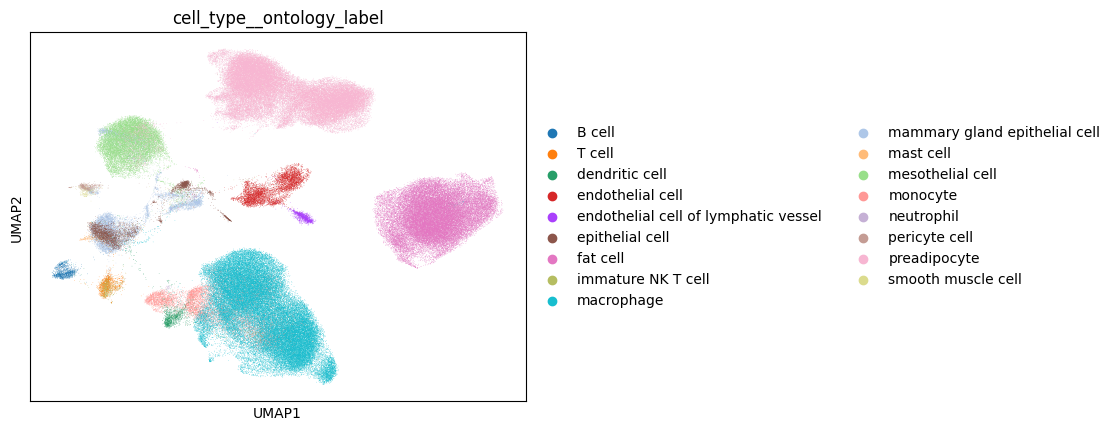

25187

In [62]:
Normalize(adata)
FindVariableGenes(adata, batch_column="Identifier")
PCA(adata)
Integrate(adata, batch_column="Identifier")
Visualize(adata)
gc.collect()

<Axes: title={'center': 'cell_type__custom'}, xlabel='LocalMAP1', ylabel='LocalMAP2'>

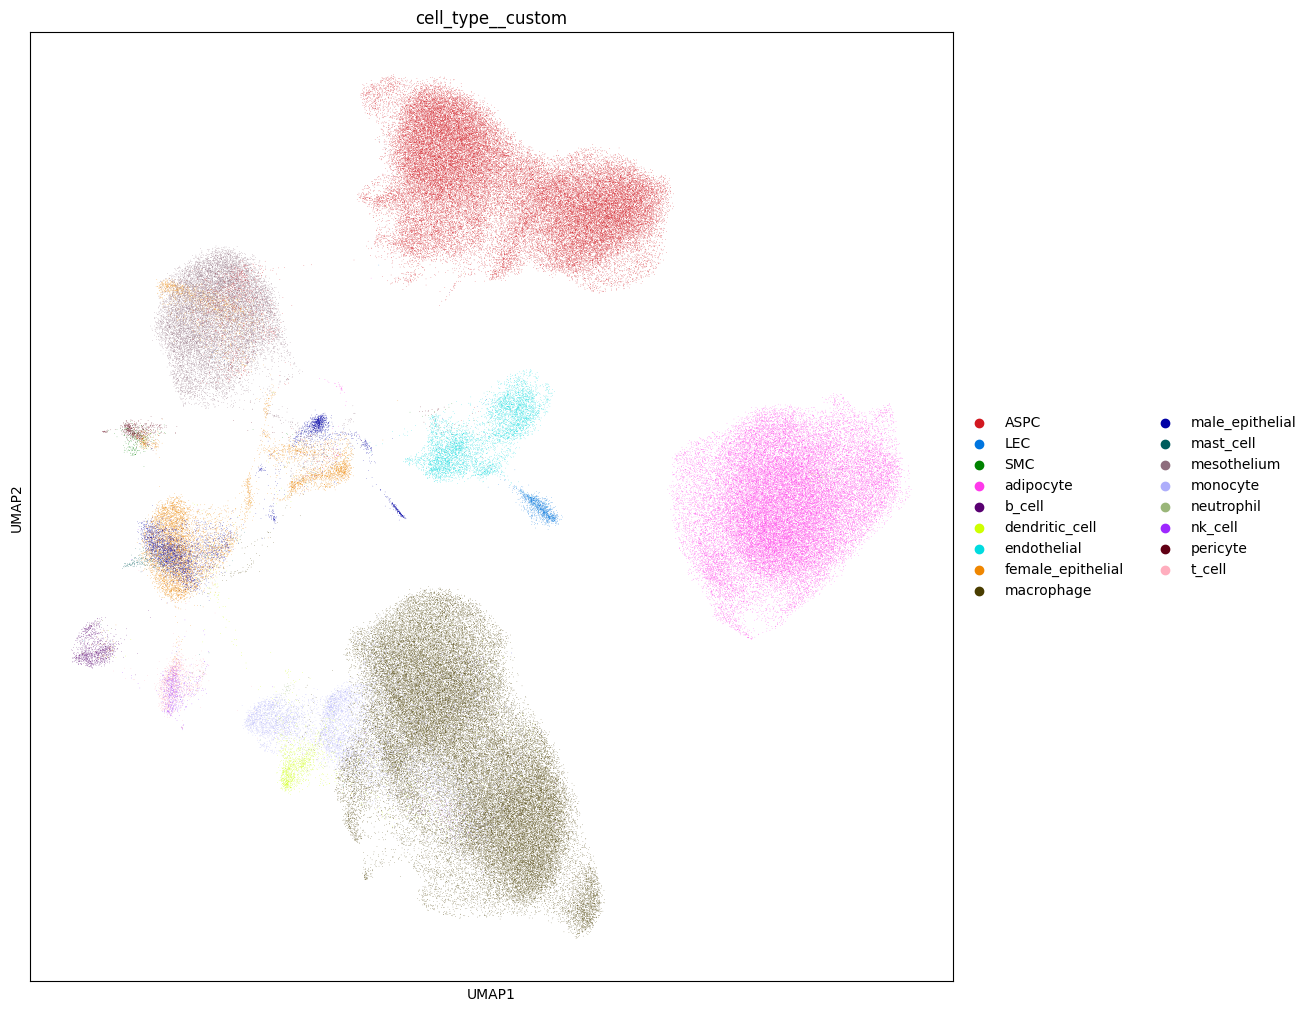

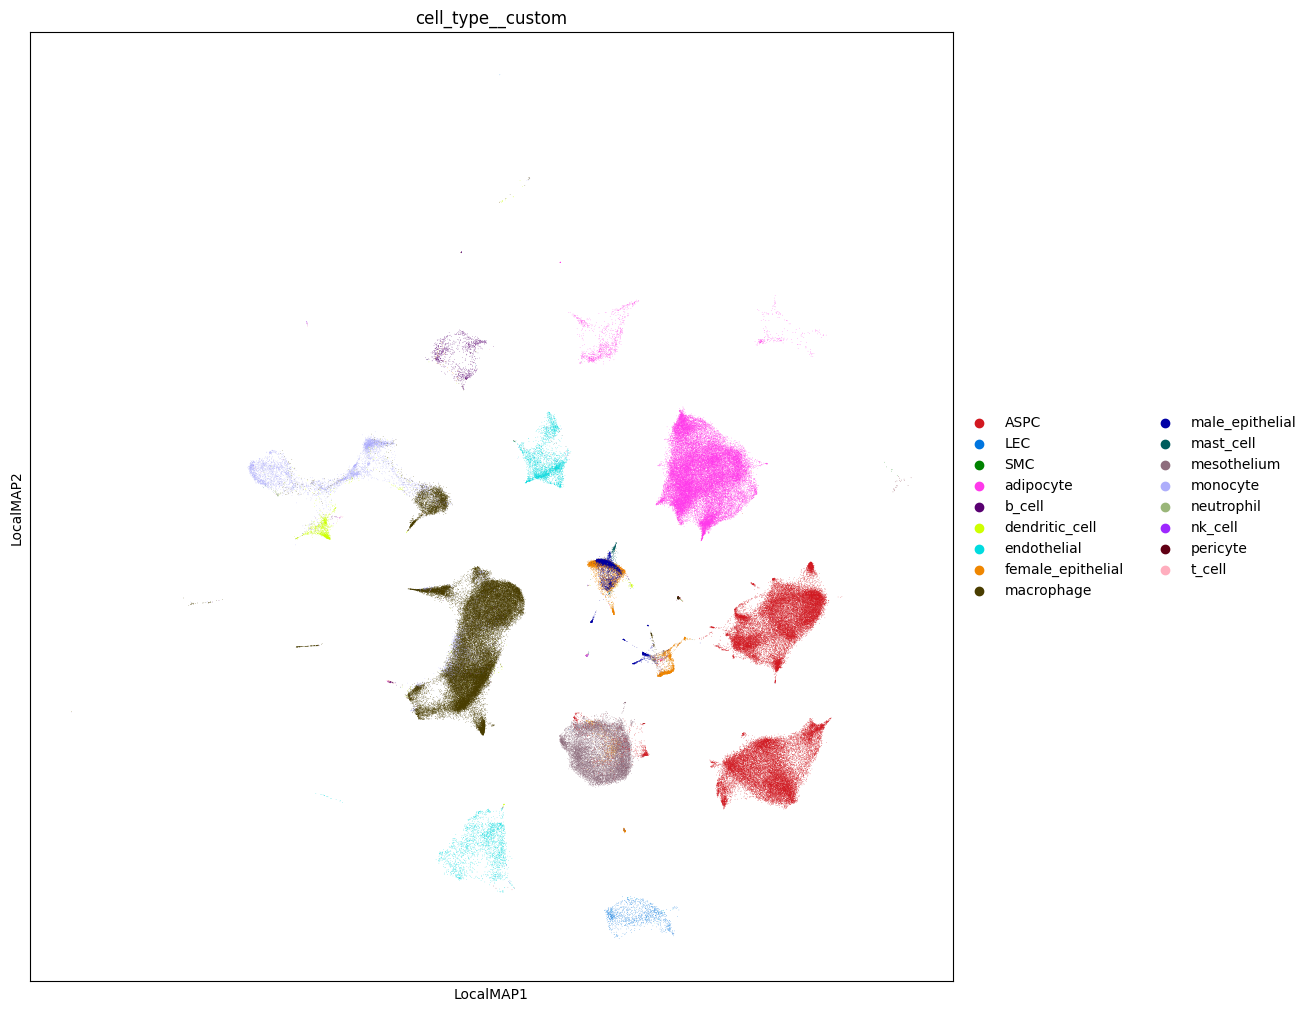

In [69]:
f, ax = plt.subplots(1, 1, layout="constrained", figsize=(13, 10))
sc.pl.embedding(adata, "UMAP", color="cell_type__custom", ax=ax, show=False)

f, ax = plt.subplots(1, 1, layout="constrained", figsize=(13, 10))
sc.pl.embedding(adata, "LocalMAP", color="cell_type__custom", ax=ax, show=False)

In [64]:
savedir = DATADIR / "processed" / "single cell" / study
adata.write_zarr(savedir / "cleaned")
print(adata)
gc.collect()

AnnData object with n_obs × n_vars = 197721 × 25180
    obs: 'Identifier', 'biosample_type', 'library_preparation_protocol__ontology_id', 'library_preparation_protocol__ontology_label', 'donor_id', 'species__ontology_id', 'species__ontology_label', 'organ__ontology_id', 'organ__ontology_label', 'tissue__ontology_id', 'tissue__ontology_label', 'tissue__type__ontology_id', 'tissue__type__ontology_label', 'depot__ontology_id', 'depot__ontology_label', 'fat__type', 'sex__ontology_id', 'sex__ontology_label', 'race__ontology_id', 'race__ontology_label', 'ethnicity__ontology_id', 'ethnicity__ontology_label', 'mouse_strain__ontology_id', 'mouse_strain__ontology_label', 'development_stage__ontology_id', 'development_stage__ontology_label', 'organism_age', 'organism_age__unit__ontology_id', 'organism_age__unit__ontology_label', 'organism_age__group', 'organism_weight', 'organism_weight__unit__ontology_id', 'organism_weight__unit__ontology_label', 'disease__ontology_id', 'disease__ontology_label'

4997

# Filter

In [ ]:
groupby = "biosample_id"

check_QCPlot(adata.obs, "n_umis", groupby)
check_QCPlot(adata.obs, "mitochondrial_percent", groupby)
check_QCPlot(adata.obs, "n_genes", groupby)